# SomaTrack — Phase 1: Data Preparation & Cleaning
**Project:** Predicting Study-Related Physical Ailments  
**Dataset:** 1,170 responses (270 original + 900 augmented)  
**Objective:** Clean, encode, and engineer features to produce an ML-ready dataset

---
## Table of Contents
1. [Setup & Data Loading](#1)
2. [Initial Inspection](#2)
3. [Handling Missing Values](#3)
4. [Feature Encoding](#4)
5. [Outlier Detection & Treatment](#5)
6. [Feature Engineering](#6)
7. [Target Variable Preparation](#7)
8. [Final Dataset Export](#8)


## 1. Setup & Data Loading

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})

df = pd.read_excel('SomaTrack_Augmented.xlsx')
print(f"Dataset shape: {df.shape}")
df.head(3)


Dataset shape: (1170, 34)


,Timestamp,"Q1. On average, how many hours per day do you spend studying while sitting?",Q2. How many days do you study per week?,Q3. What is the longest continuous sitting time without a break ?,Q4. Do you take breaks while studying?,Q5. How long does your break usually last ?,"Q6. During study breaks, do you usually leave your desk?",Q7. How many liters of water do you drink on a typical study day?,Q8. How often do you consume caffeinated or energy drinks during study periods?,Q9. What is your average daily screen time (phone + laptop/tablet combined) in hours ?,...,Q24. How often have you experienced TENSION HEADACHES linked to study sessions?,Q25. How often have you experienced WRIST PAIN linked to study sessions?,Q26. How often have you experienced EYE STRAIN linked to study sessions?,Q27. How often have you experienced FINGER NUMBNESS linked to study sessions?,"Q28. Overall, what best describes your general physical discomfort level related to studying?",Q29. Age,Q30. Gender,Q31. What type of institution do you attend ?,Q32. What's your main field of study ?,Q33. What is your current year of study?
0,2026-02-27 00:06:44,6.0,5,2.25,Every 1-2 hours,5 - 10 minutes,"No, I stay seated",Less than 1L,1–2 times per week,7.0,...,2 — Moderate / regular (a few times a week),0 — Never,2 — Moderate / regular (a few times a week),1 — Mild / occasional (once or twice),2 — Frequent discomfort (affects my focus),19.0,Female,National Higher School (École Superieure),Medical & Health Sciences,1st year
1,2026-02-27 02:37:15,6.0,6,2.25,Every 30-60 minutes,5 - 10 minutes,Sometimes,1.5-2L,1–2 times per week,3.5,...,0 — Never,0 — Never,1 — Mild / occasional (once or twice),1 — Mild / occasional (once or twice),1 — Mild / occasional discomfort,20.0,Female,Public University,Medical & Health Sciences,3rd year
2,2026-02-27 06:27:27,10.0,3,2.00,Every 30-60 minutes,10 - 30 minutes,"Yes, I walk or move around or just lie down on...",Less than 1L,1–2 times per week,5.5,...,3 — Frequent / chronic (almost daily),1 — Mild / occasional (once or twice),2 — Moderate / regular (a few times a week),2 — Moderate / regular (a few times a week),3 — Chronic pain (affects my daily life),21.0,Female,Public University,Architecture & Urban Planning,3rd year


## 2. Initial Inspection

In [39]:
print("=== COLUMN TYPES ===")
print(df.dtypes.to_string())
print(f"\nRows: {len(df)} | Cols: {len(df.columns)}")


=== COLUMN TYPES ===
Timestamp                                                                                                              datetime64[ns]
Q1. On average, how many hours per day do you spend studying while sitting?                                                   float64
Q2. How many days do you study per week?                                                                                        int64
Q3. What is the longest continuous sitting time without a break ?                                                             float64
Q4. Do you take breaks while studying?                                                                                         object
Q5. How long does your break usually last ?                                                                                    object
Q6. During study breaks, do you usually leave your desk?                                                                       object
Q7. How many liters of water do you drink

In [40]:
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Count': missing, '%': pct})
miss_df = miss_df[miss_df['Count'] > 0].sort_values('%', ascending=False)
print("=== MISSING VALUES ===")
print(miss_df.to_string() if len(miss_df) else "None")


=== MISSING VALUES ===
                                                                     Count     %
Q33. What is your current year of study?                                10  0.85
Q32. What's your main field of study ?                                   7  0.60
Q29. Age                                                                 7  0.60
Q30. Gender                                                              6  0.51
Q31. What type of institution do you attend ?                            5  0.43
Q10. How would you rate your stress level during study periods?          2  0.17
Q18. On average, how heavy is your backpack on a typical study day?      1  0.09


In [41]:
num_cols = ['Q1. On average, how many hours per day do you spend studying while sitting?',
            'Q2. How many days do you study per week?',
            'Q3. What is the longest continuous sitting time without a break ?',
            'Q9. What is your average daily screen time (phone + laptop/tablet combined) in hours ?',
            'Q29. Age']
df[num_cols].describe().round(2)


,"Q1. On average, how many hours per day do you spend studying while sitting?",Q2. How many days do you study per week?,Q3. What is the longest continuous sitting time without a break ?,Q9. What is your average daily screen time (phone + laptop/tablet combined) in hours ?,Q29. Age
count,1170.00,1170.00,1170.00,1170.00,1163.00
mean,4.56,4.71,3.10,7.07,19.48
std,2.59,1.64,2.36,2.90,1.50
min,0.00,1.00,0.00,1.00,16.00
25%,2.50,3.00,1.50,5.00,18.00
50%,4.00,5.00,2.50,7.00,20.00
75%,6.00,6.00,4.00,9.00,20.00
max,24.00,7.00,17.00,15.00,24.00


## 3. Handling Missing Values

In [42]:
# Drop Q31 (institution) , Q32 (field of study) and Q33. (year of study)  — not predictive per project spec
df = df.drop(columns=[
    'Q31. What type of institution do you attend ?',
    "Q32. What's your main field of study ?",
    "Q33. What is your current year of study?"
])
print(f"Shape after dropping Q31 & Q32: {df.shape}")


Shape after dropping Q31 & Q32: (1170, 31)


In [43]:
# Q10 stress: 2 missing → mode imputation
q10 = 'Q10. How would you rate your stress level during study periods?'
mode_q10 = df[q10].mode()[0]
df[q10] = df[q10].fillna(mode_q10)
print(f"Q10 filled with mode: '{mode_q10}' | remaining NaN: {df[q10].isna().sum()}")

# Q18 backpack: 1 missing → mode imputation
q18 = 'Q18. On average, how heavy is your backpack on a typical study day?'
mode_q18 = df[q18].mode()[0]
df[q18] = df[q18].fillna(mode_q18)
print(f"Q18 filled with mode: '{mode_q18}' | remaining NaN: {df[q18].isna().sum()}")

# Q29 age: missing → median
q29 = 'Q29. Age'
median_age = df[q29].median()
df[q29] = df[q29].fillna(median_age).round().astype(int)
print(f"Q29 filled with median: {median_age:.0f} | remaining NaN: {df[q29].isna().sum()}")

# Q30 gender: missing → 'Unknown'
q30 = 'Q30. Gender '
df[q30] = df[q30].fillna('Unknown')
print(f"Q30 filled with 'Unknown' | remaining NaN: {df[q30].isna().sum()}")



print(f"\nTotal remaining missing values: {df.isnull().sum().sum()}")
assert df.isnull().sum().sum() == 0, "Still have missing values!"
print("✓ All missing values resolved.")


Q10 filled with mode: 'Moderate' | remaining NaN: 0
Q18 filled with mode: 'Less than 3 kg' | remaining NaN: 0
Q29 filled with median: 20 | remaining NaN: 0
Q30 filled with 'Unknown' | remaining NaN: 0

Total remaining missing values: 0
✓ All missing values resolved.


## 4. Feature Encoding

Three strategies used:
- **Ordinal encoding**: features with a natural order (posture, stress, sleep, etc.)
- **Multi-hot flags**: pre-existing conditions (multiple conditions possible)
- **One-hot encoding**: nominal categories (study location, seat type, input method)


In [44]:
df_enc = df.drop(columns=['Timestamp']).copy()

# ── Rename to short feature names ────────────────────────────────────────────
col_rename = {
    'Q1. On average, how many hours per day do you spend studying while sitting?': 'sitting_hours',
    'Q2. How many days do you study per week?': 'study_days_week',
    'Q3. What is the longest continuous sitting time without a break ?': 'max_continuous_sit',
    'Q4. Do you take breaks while studying?': 'break_frequency',
    'Q5. How long does your break usually last ?': 'break_duration',
    'Q6. During study breaks, do you usually leave your desk?': 'leave_desk',
    'Q7. How many liters of water do you drink on a typical study day?': 'water_intake',
    'Q8. How often do you consume caffeinated or energy drinks during study periods?': 'caffeine_freq',
    'Q9. What is your average daily screen time (phone + laptop/tablet combined) in hours ?': 'screen_time',
    'Q10. How would you rate your stress level during study periods?': 'stress_level',
    'Q11. Where do you primarily study?': 'study_location',
    'Q12. What type of seat do you most often use while studying?': 'seat_type',
    'Q13. When working on a laptop, what input method do you primarily use?': 'input_method',
    'Q14. How would you describe your posture during most study sessions?': 'posture',
    'Q15. Do you usually lean on your back while studying?': 'lean_back',
    'Q16. Is your screen at eye level when you study?': 'screen_eye_level',
    'Q17. Do you have any pre-existing medical condition or past injury affecting your back, neck, shoulders, or wrists?': 'preexisting_condition',
    'Q18. On average, how heavy is your backpack on a typical study day?': 'backpack_weight',
    'Q19. How would you describe your usual study lighting conditions?': 'lighting',
    'Q20. Do you practice physical exercise weekly?': 'exercise_freq',
    "Q21. What's your average sleep duration per night ?": 'sleep_duration',
    'Q22. How often have you experienced BACK PAIN while or after studying?': 'target_back_pain',
    'Q23. How often have you experienced NECK STRAIN while or after studying?': 'target_neck_strain',
    'Q24. How often have you experienced TENSION HEADACHES linked to study sessions?': 'target_headache',
    'Q25. How often have you experienced WRIST PAIN linked to study sessions?': 'target_wrist_pain',
    'Q26. How often have you experienced EYE STRAIN linked to study sessions?': 'target_eye_strain',
    'Q27. How often have you experienced FINGER NUMBNESS linked to study sessions?': 'target_finger_numb',
    'Q28.  Overall, what best describes your general physical discomfort level related to studying?': 'target_overall',
    'Q29. Age': 'age',
    'Q30. Gender ': 'gender',
}
df_enc = df_enc.rename(columns=col_rename)
print("Columns renamed. New shape:", df_enc.shape)


Columns renamed. New shape: (1170, 30)


### 4.1 Normalize Unicode Apostrophes

In [45]:
# Normalize curly vs. straight apostrophes (data entry artifact)
str_cols = df_enc.select_dtypes(include='object').columns
for col in str_cols:
    df_enc[col] = (df_enc[col]
                   .astype(str)
                   .str.replace('\u2019', "'", regex=False)
                   .str.replace('\u2018', "'", regex=False))
    df_enc[col] = df_enc[col].where(df_enc[col] != 'nan', other=np.nan)
print("Unicode normalization done.")


Unicode normalization done.


### 4.2 Ordinal Encoding

In [46]:
ordinal_maps = {
    'break_frequency': {
        'Never': 0, 'Rarely': 1, 'Every 1-2 hours': 2, 'Every 30-60 minutes': 3
    },
    'break_duration': {
        "I don't take breaks": 0, 'Less than 5 minutes': 1,
        '5 - 10 minutes': 2, '10 - 30 minutes': 3, 'More than 30 minutes': 4
    },
    'leave_desk': {
        "I don't take breaks": 0, 'No, I stay seated': 1,
        'Sometimes': 2, 'Yes, I walk or move around or just lie down on a bed or sofa': 3
    },
    'water_intake': {
        'Less than 1L': 0, '1-1.5L': 1, '1.5-2L': 2, 'More than 2L': 3
    },
    'caffeine_freq': {
        'Never': 0, '1–2 times per week': 1, '3–5 times per week': 2,
        '1 drink per day': 3, '+2 drinks per day': 4
    },
    'stress_level':  {'Low': 0, 'Moderate': 1, 'High': 2},
    'posture': {
        'Upright / straight back': 0, 'Slightly slouched': 1,
        'Heavily slouched / hunched': 2, 'Lying down': 3
    },
    'screen_eye_level': {
        'Yes, always': 0, 'Sometimes': 1, 'No, I look down at it most of the time': 2
    },
    'lean_back':  {'No': 0, 'Sometimes': 1, 'Yes': 2},
    'backpack_weight': {
        'I rarely carry a backpack': 0, 'Less than 3 kg': 1,
        '3–5 kg': 2, '5–8 kg': 3, 'More than 8 kg': 4
    },
    'lighting': {
        'Dim lighting': 0, 'Mixed (natural + artificial)': 1,
        'Bright artificial lighting': 2, 'Natural daylight': 3
    },
    'exercise_freq': {'No': 0, '1 – 2 times': 1, '3 – 4 times': 2, '+5 times': 3},
    'sleep_duration': {
        'Less than 5h': 0, '5 – 6h': 1, '6 – 7h': 2, '7 – 8h': 3, 'More than 8h': 4
    },
    'gender': {'Female': 0, 'Male': 1, 'Unknown': 2},
}

for col, mapping in ordinal_maps.items():
    df_enc[col] = df_enc[col].map(mapping)
    nan_after = df_enc[col].isna().sum()
    if nan_after > 0:
        med = df_enc[col].median()
        df_enc[col] = df_enc[col].fillna(med)
        print(f"  {col}: filled {nan_after} unmapped values with median={med:.1f}")
    df_enc[col] = df_enc[col].astype(int)

print("\nOrdinal encoding complete. Sample:")
print(df_enc[['break_frequency', 'stress_level', 'posture', 'sleep_duration', 'exercise_freq']].head(3).to_string())



Ordinal encoding complete. Sample:
   break_frequency  stress_level  posture  sleep_duration  exercise_freq
0                2             2        2               1              0
1                3             1        1               1              0
2                3             2        2               1              1


### 4.3 Pre-Existing Condition → Multi-Hot Flags

In [47]:
df_enc['has_back_condition']  = df_enc['preexisting_condition'].str.contains('Back',  na=False).astype(int)
df_enc['has_neck_condition']  = df_enc['preexisting_condition'].str.contains('Neck',  na=False).astype(int)
df_enc['has_wrist_condition'] = df_enc['preexisting_condition'].str.contains('Wrist', na=False).astype(int)
df_enc = df_enc.drop(columns=['preexisting_condition'])

print("Condition flag counts:")
print(df_enc[['has_back_condition','has_neck_condition','has_wrist_condition']].sum().to_string())


Condition flag counts:
has_back_condition     282
has_neck_condition     131
has_wrist_condition     88


### 4.4 One-Hot Encoding (Nominal)

In [48]:
nominal_cols = ['study_location', 'seat_type', 'input_method']
df_enc = pd.get_dummies(df_enc, columns=nominal_cols, drop_first=False, dtype=int)

# Clean column names
df_enc.columns = (
    df_enc.columns
    .str.lower()
    .str.replace(r'[^a-z0-9_]', '_', regex=True)
    .str.replace(r'_+', '_', regex=True)
    .str.strip('_')
)

ohe_new = [c for c in df_enc.columns
           if any(c.startswith(p) for p in ['study_location', 'seat_type', 'input_method'])]
print(f"Shape after OHE: {df_enc.shape}")
print(f"New OHE columns ({len(ohe_new)}): {ohe_new}")


Shape after OHE: (1170, 46)
New OHE columns (17): ['study_location_bed', 'study_location_classroom', 'study_location_desk_at_home_dorm', 'study_location_library', 'study_location_other', 'seat_type_bed_floor_no_chair', 'seat_type_ergonomic_office_chair_with_back_support', 'seat_type_other', 'seat_type_plastic_chair_standard', 'seat_type_sofa_couch', 'seat_type_stool_no_backrest', 'seat_type_wooden_chair', 'input_method_external_keyboard_mouse', 'input_method_external_keyboard_only', 'input_method_external_mouse_only', 'input_method_i_mainly_use_a_desktop_pc', 'input_method_laptop_trackpad_only']


### 4.5 Target Variable Encoding

In [49]:
pain_map = {
    '0 — Never': 0,
    '1 — Mild / occasional (once or twice)': 1,
    '2 — Moderate / regular (a few times a week)': 2,
    '3 — Frequent / chronic (almost daily)': 3,
}
overall_map = {
    '0 — No pain at all': 0,
    '1 — Mild / occasional discomfort': 1,
    '2 — Frequent discomfort (affects my focus)': 2,
    '3 — Chronic pain (affects my daily life)': 3,
}

target_pain_cols = [
    'target_back_pain', 'target_neck_strain', 'target_headache',
    'target_wrist_pain', 'target_eye_strain', 'target_finger_numb'
]
for col in target_pain_cols:
    df_enc[col] = df_enc[col].map(pain_map).astype(int)

df_enc['target_overall'] = df_enc['target_overall'].map(overall_map).astype(int)

print("Target distributions (0=None, 1=Mild, 2=Moderate, 3=Chronic):")
for col in target_pain_cols + ['target_overall']:
    print(f"  {col:30s}: {df_enc[col].value_counts().sort_index().to_dict()}")


Target distributions (0=None, 1=Mild, 2=Moderate, 3=Chronic):
  target_back_pain              : {0: 98, 1: 320, 2: 362, 3: 390}
  target_neck_strain            : {0: 166, 1: 382, 2: 378, 3: 244}
  target_headache               : {0: 172, 1: 390, 2: 366, 3: 242}
  target_wrist_pain             : {0: 445, 1: 375, 2: 235, 3: 115}
  target_eye_strain             : {0: 145, 1: 357, 2: 387, 3: 281}
  target_finger_numb            : {0: 393, 1: 434, 2: 230, 3: 113}
  target_overall                : {0: 85, 1: 675, 2: 377, 3: 33}


## 5. Outlier Detection & Treatment

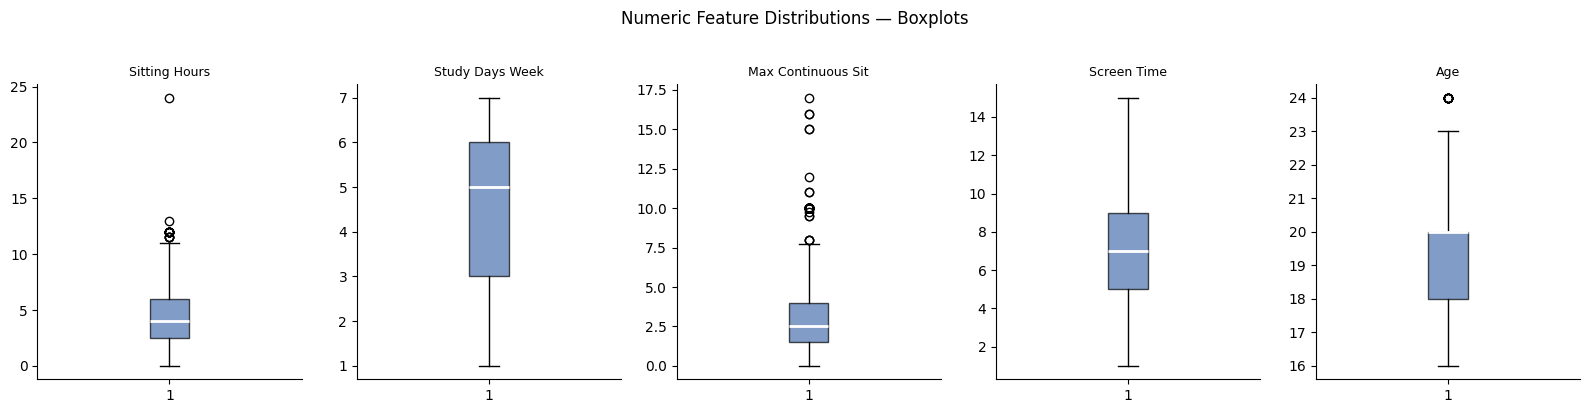

In [ ]:
numeric_features = ['sitting_hours', 'study_days_week', 'max_continuous_sit', 'screen_time', 'age']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(16, 4))
for ax, col in zip(axes, numeric_features):
    ax.boxplot(df_enc[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.7),
               medianprops=dict(color='white', linewidth=2))
    ax.set_title(col.replace('_', ' ').title(), fontsize=9)
plt.suptitle('Numeric Feature Distributions — Boxplots', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


In [51]:
print("=== IQR OUTLIER SUMMARY ===")
for col in numeric_features:
    Q1, Q3 = df_enc[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df_enc[col] < lo) | (df_enc[col] > hi)).sum()
    print(f"  {col:25s}  [{lo:.1f}, {hi:.1f}]  outliers={n_out}")


=== IQR OUTLIER SUMMARY ===
  sitting_hours              [-2.8, 11.2]  outliers=21
  study_days_week            [-1.5, 10.5]  outliers=0
  max_continuous_sit         [-2.2, 7.8]  outliers=66
  screen_time                [-1.0, 15.0]  outliers=0
  age                        [15.0, 23.0]  outliers=11


In [52]:
# Clip continuous features at 1st/99th percentile to reduce extreme values
for col in ['sitting_hours', 'max_continuous_sit', 'screen_time']:
    p01 = df_enc[col].quantile(0.01)
    p99 = df_enc[col].quantile(0.99)
    df_enc[col] = df_enc[col].clip(lower=p01, upper=p99)
    print(f"  {col}: clipped to [{p01:.2f}, {p99:.2f}]")

print("\n✓ Outlier treatment complete.")


  sitting_hours: clipped to [0.00, 12.00]
  max_continuous_sit: clipped to [0.00, 10.00]
  screen_time: clipped to [2.00, 15.00]

✓ Outlier treatment complete.


## 6. Feature Engineering

Domain-informed composite features that capture interaction effects known to drive ergonomic discomfort.


In [53]:
# Sitting-to-break ratio: longer uninterrupted sitting relative to break duration → higher risk
df_enc['sit_break_ratio'] = df_enc['max_continuous_sit'] / (df_enc['break_duration'] + 1)

# Ergonomic risk score: sum of three postural risk indicators
# posture (0=good → 3=lying), screen_eye_level (0=ok → 2=bad), lean_back (0→2)
df_enc['ergonomic_risk'] = df_enc['posture'] + df_enc['screen_eye_level'] + df_enc['lean_back']

# Activity balance: exercise frequency vs sitting exposure (normalized)
df_enc['activity_balance'] = df_enc['exercise_freq'] - (df_enc['sitting_hours'] / 4)

# Sleep–stress index: poor sleep amplifies high-stress pain risk
df_enc['sleep_stress_index'] = (4 - df_enc['sleep_duration']) * (df_enc['stress_level'] + 1)

# Hydration index: water intake relative to sitting exposure
df_enc['hydration_index'] = df_enc['water_intake'] / (df_enc['sitting_hours'] + 1)

# Digital load: total screen exposure across study week
df_enc['digital_load'] = df_enc['screen_time'] * df_enc['study_days_week']

engineered = ['sit_break_ratio', 'ergonomic_risk', 'activity_balance',
              'sleep_stress_index', 'hydration_index', 'digital_load']

print("Engineered feature summary:")
df_enc[engineered].describe().round(3)


Engineered feature summary:


,sit_break_ratio,ergonomic_risk,activity_balance,sleep_stress_index,hydration_index,digital_load
count,1170.000,1170.000,1170.000,1170.000,1170.000,1170.000
mean,0.866,3.521,-0.503,4.548,0.261,33.624
std,0.739,1.237,1.047,2.884,0.340,19.169
min,0.000,0.000,-3.000,0.000,0.000,2.000
25%,0.417,3.000,-1.250,2.000,0.000,20.000
50%,0.688,3.000,-0.625,4.000,0.182,30.000
75%,1.062,4.000,0.125,6.000,0.353,45.500
max,10.000,7.000,3.000,12.000,3.000,105.000


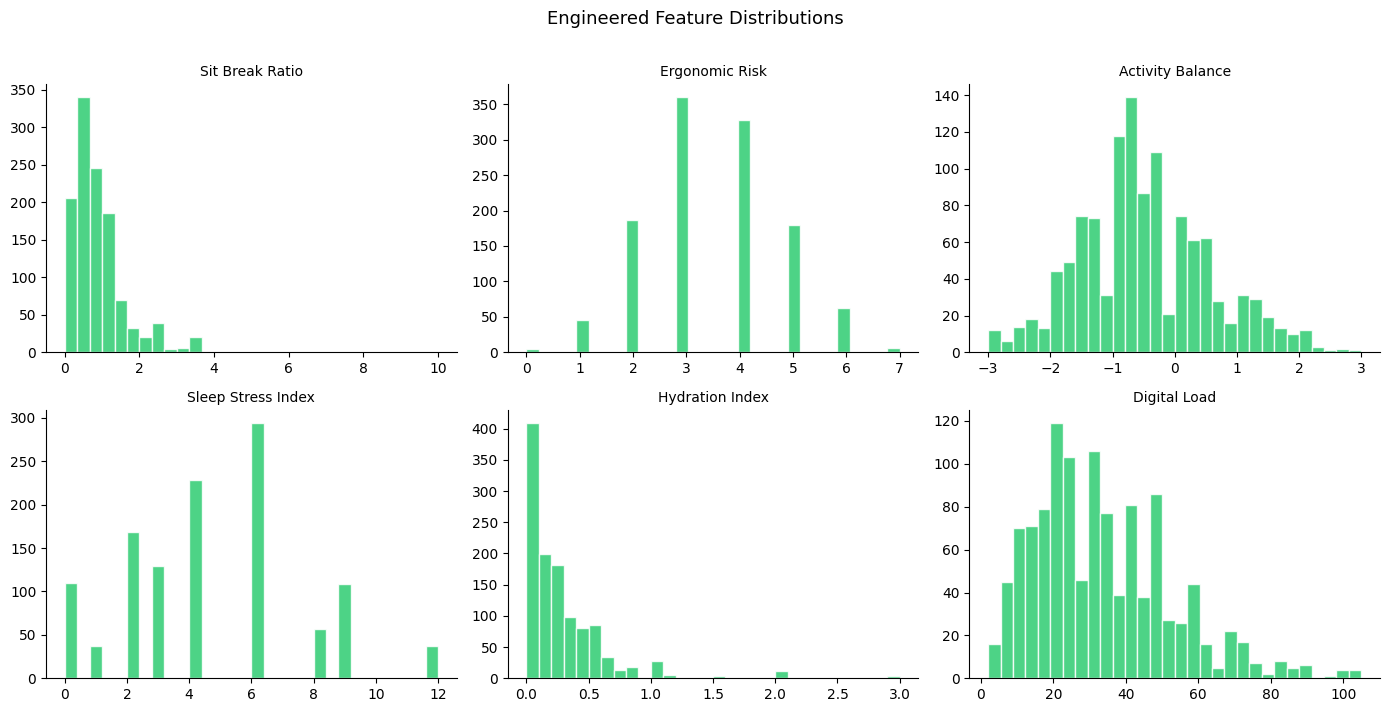

In [ ]:
# Visualize engineered features
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), engineered):
    ax.hist(df_enc[col], bins=30, color='#2ecc71', edgecolor='white', alpha=0.85)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('')
plt.suptitle('Engineered Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 7. Target Variable Preparation

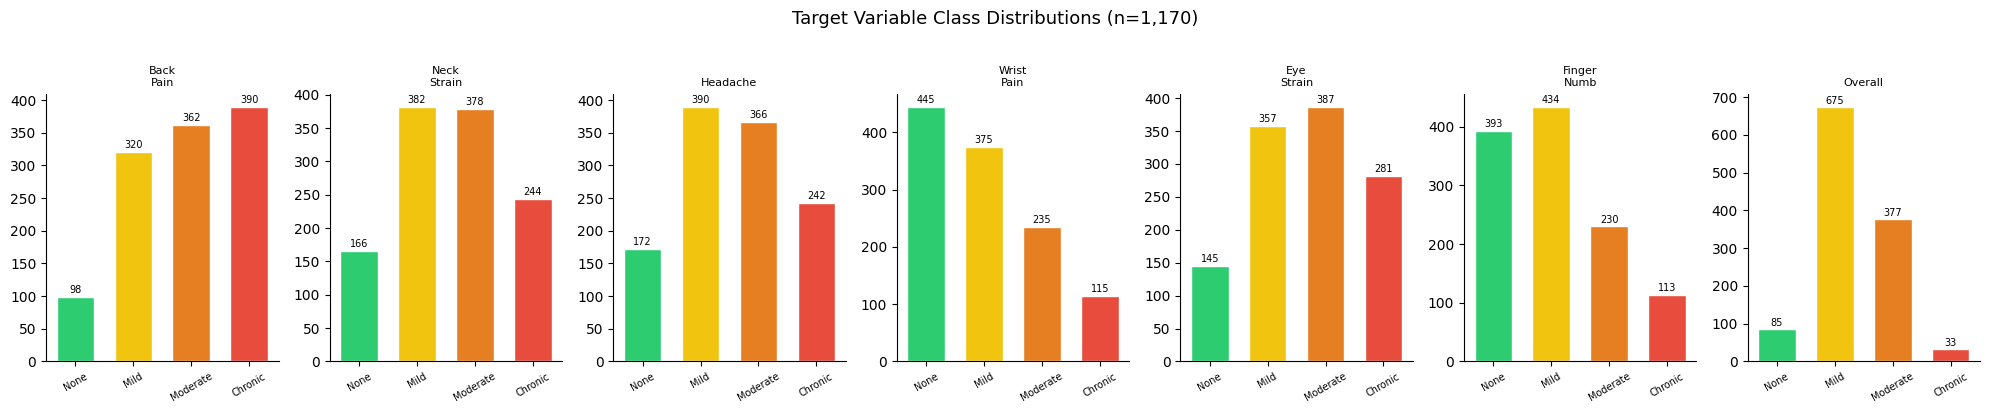

In [ ]:
all_targets = [
    'target_back_pain', 'target_neck_strain', 'target_headache',
    'target_wrist_pain', 'target_eye_strain', 'target_finger_numb', 'target_overall'
]
label_names = ['None', 'Mild', 'Moderate', 'Chronic']
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(1, len(all_targets), figsize=(20, 4))
for ax, col in zip(axes, all_targets):
    counts = df_enc[col].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color=colors[:len(counts)],
                  edgecolor='white', width=0.65)
    ax.set_title(col.replace('target_', '').replace('_', '\n').title(), fontsize=8)
    ax.set_xticks(range(4))
    ax.set_xticklabels(label_names, fontsize=7, rotation=30)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(v), ha='center', va='bottom', fontsize=7)

plt.suptitle('Target Variable Class Distributions (n=1,170)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [56]:
print("=== CLASS BALANCE SUMMARY ===")
for col in all_targets:
    counts = df_enc[col].value_counts(normalize=True).sort_index()
    ratio = ' | '.join([f"{k}:{v:.1%}" for k, v in counts.items()])
    flag  = ' ⚠ imbalanced' if counts.min() < 0.10 else ''
    print(f"  {col:32s}  {ratio}{flag}")


=== CLASS BALANCE SUMMARY ===
  target_back_pain                  0:8.4% | 1:27.4% | 2:30.9% | 3:33.3% ⚠ imbalanced
  target_neck_strain                0:14.2% | 1:32.6% | 2:32.3% | 3:20.9%
  target_headache                   0:14.7% | 1:33.3% | 2:31.3% | 3:20.7%
  target_wrist_pain                 0:38.0% | 1:32.1% | 2:20.1% | 3:9.8% ⚠ imbalanced
  target_eye_strain                 0:12.4% | 1:30.5% | 2:33.1% | 3:24.0%
  target_finger_numb                0:33.6% | 1:37.1% | 2:19.7% | 3:9.7% ⚠ imbalanced
  target_overall                    0:7.3% | 1:57.7% | 2:32.2% | 3:2.8% ⚠ imbalanced


## 8. Final Dataset Export

In [57]:
target_cols  = [c for c in df_enc.columns if c.startswith('target_')]
feature_cols = [c for c in df_enc.columns if not c.startswith('target_')]

X = df_enc[feature_cols]
y = df_enc[target_cols]

print(f"Feature matrix X : {X.shape}")
print(f"Target  matrix y : {y.shape}")
print(f"\nFeature columns ({len(feature_cols)}):")
for c in feature_cols:
    print(f"  {c}")


Feature matrix X : (1170, 45)
Target  matrix y : (1170, 7)

Feature columns (45):
  sitting_hours
  study_days_week
  max_continuous_sit
  break_frequency
  break_duration
  leave_desk
  water_intake
  caffeine_freq
  screen_time
  stress_level
  posture
  lean_back
  screen_eye_level
  backpack_weight
  lighting
  exercise_freq
  sleep_duration
  age
  gender
  has_back_condition
  has_neck_condition
  has_wrist_condition
  study_location_bed
  study_location_classroom
  study_location_desk_at_home_dorm
  study_location_library
  study_location_other
  seat_type_bed_floor_no_chair
  seat_type_ergonomic_office_chair_with_back_support
  seat_type_other
  seat_type_plastic_chair_standard
  seat_type_sofa_couch
  seat_type_stool_no_backrest
  seat_type_wooden_chair
  input_method_external_keyboard_mouse
  input_method_external_keyboard_only
  input_method_external_mouse_only
  input_method_i_mainly_use_a_desktop_pc
  input_method_laptop_trackpad_only
  sit_break_ratio
  ergonomic_risk
  a

In [58]:
nan_left = df_enc.isnull().sum().sum()
assert nan_left == 0, f"Found {nan_left} remaining NaN values!"
print(f"✓ Zero missing values confirmed.")

# Save ML-ready CSV
df_enc.to_csv('SomaTrack_ML_Ready.csv', index=False)
print(f"✓ Saved  SomaTrack_ML_Ready.csv  ({df_enc.shape[0]} rows × {df_enc.shape[1]} cols)")

# Save metadata for Phase 2+
metadata = {
    'feature_cols': feature_cols,
    'target_cols': target_cols,
    'numeric_features': ['sitting_hours','study_days_week','max_continuous_sit','screen_time','age'],
    'engineered_features': ['sit_break_ratio','ergonomic_risk','activity_balance',
                            'sleep_stress_index','hydration_index','digital_load'],
    'n_samples': len(df_enc)
}
with open('somatrack_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("✓ Saved  somatrack_metadata.json")


✓ Zero missing values confirmed.
✓ Saved  SomaTrack_ML_Ready.csv  (1170 rows × 52 cols)
✓ Saved  somatrack_metadata.json


In [59]:
print("=== FINAL DATASET SUMMARY ===")
print(f"Total samples   : {df_enc.shape[0]}")
print(f"Feature columns : {len(feature_cols)}")
print(f"Target columns  : {len(target_cols)}")
print(f"Missing values  : {df_enc.isnull().sum().sum()}")
print()
print("Data types breakdown:")
print(df_enc.dtypes.value_counts().to_string())


=== FINAL DATASET SUMMARY ===
Total samples   : 1170
Feature columns : 45
Target columns  : 7
Missing values  : 0

Data types breakdown:
int64      45
float64     7
